In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [5]:
data = pd.read_csv("../data/raw/disaster_prediction_dataset.csv")
data.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
3,2024-9796-USA,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,USA,...,NaN,NaN,NaN,5400000.0,5400000.0,100.000000,NaN,"[{""gid_1"":""USA.13_1"",""name_1"":""Idaho""},{""gid_1...",2024-10-29,2025-12-20
4,2000-0620-NGA,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,NaN,NaN,NGA,...,NaN,NaN,NaN,4805.0,8753.0,54.895152,"[{""adm1_code"":2230,""adm1_name"":""Lagos""}]","[{""gid_1"":""NGA.25_1"",""migration_date"":""2025-12...",2005-09-15,2025-12-20


In [6]:
data.shape

(10643, 47)

In [6]:
data["Disaster Type"].nunique()

14

In [7]:
data["Disaster Type"].unique()

<StringArray>
[                      'Flood',                    'Wildfire',
                     'Drought',         'Mass movement (wet)',
           'Volcanic activity',                       'Storm',
                    'Epidemic',                  'Earthquake',
         'Extreme temperature',                 'Infestation',
 'Glacial lake outburst flood',         'Mass movement (dry)',
             'Animal incident',                      'Impact']
Length: 14, dtype: str

In [8]:
data["Disaster Type"].value_counts()

Disaster Type
Flood                          4239
Storm                          2815
Epidemic                        890
Earthquake                      693
Extreme temperature             568
Mass movement (wet)             495
Drought                         420
Wildfire                        337
Volcanic activity               133
Infestation                      29
Mass movement (dry)              14
Glacial lake outburst flood       8
Animal incident                   1
Impact                            1
Name: count, dtype: int64

In [9]:
(data["Disaster Type"].value_counts(normalize=True)*100).round(2)

Disaster Type
Flood                          39.83
Storm                          26.45
Epidemic                        8.36
Earthquake                      6.51
Extreme temperature             5.34
Mass movement (wet)             4.65
Drought                         3.95
Wildfire                        3.17
Volcanic activity               1.25
Infestation                     0.27
Mass movement (dry)             0.13
Glacial lake outburst flood     0.08
Animal incident                 0.01
Impact                          0.01
Name: proportion, dtype: float64

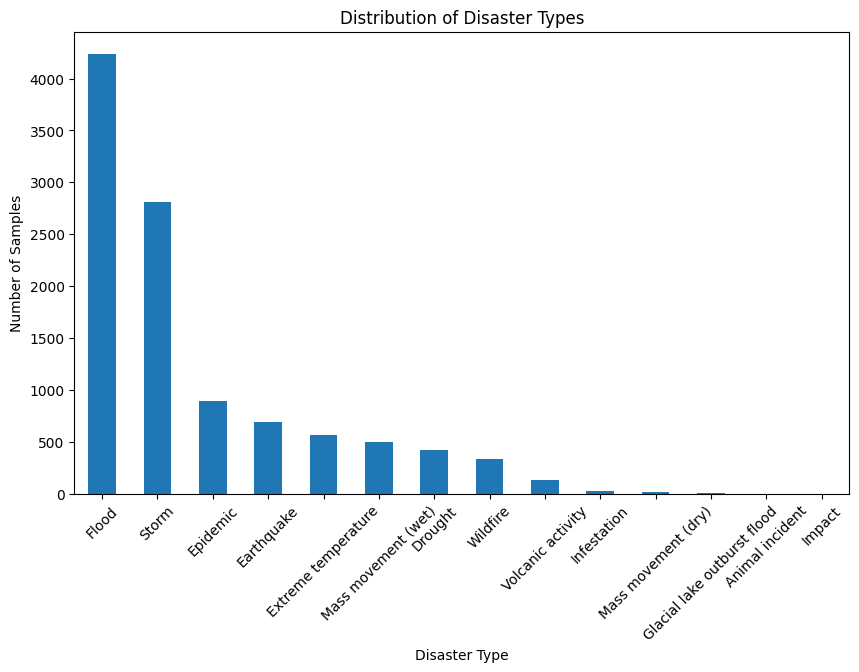

In [10]:
plt.figure(figsize=(10,6))
data["Disaster Type"].value_counts().plot(kind="bar")
plt.title("Distribution of Disaster Types")
plt.xlabel("Disaster Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [11]:
data["Disaster Type"].value_counts().describe()

count      14.000000
mean      760.214286
std      1238.831470
min         1.000000
25%        17.750000
50%       378.500000
75%       661.750000
max      4239.000000
Name: count, dtype: float64

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10643 entries, 0 to 10642
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     10643 non-null  str    
 1   Historic                                   10643 non-null  str    
 2   Classification Key                         10643 non-null  str    
 3   Disaster Group                             10643 non-null  str    
 4   Disaster Subgroup                          10643 non-null  str    
 5   Disaster Type                              10643 non-null  str    
 6   Disaster Subtype                           10643 non-null  str    
 7   External IDs                               4258 non-null   str    
 8   Event Name                                 2631 non-null   str    
 9   ISO                                        10643 non-null  str    
 10  Country                          

In [13]:
data["Start Year"].describe()

count    10643.000000
mean      2012.242883
std          7.684883
min       2000.000000
25%       2005.000000
50%       2012.000000
75%       2019.000000
max       2026.000000
Name: Start Year, dtype: float64

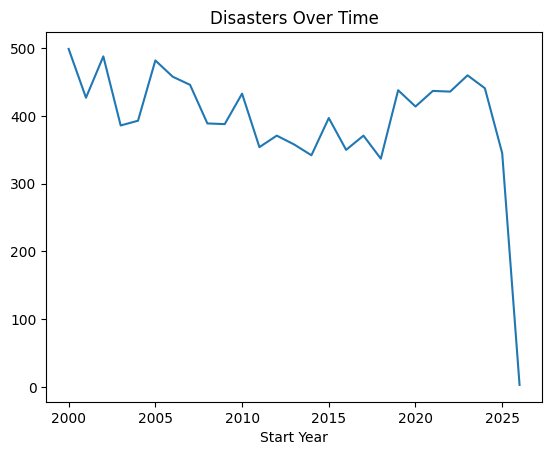

In [14]:
data["Start Year"].value_counts().sort_index().plot()
plt.title("Disasters Over Time")
plt.show()

In [15]:
data["Region"].value_counts()

Region
Asia        4164
Americas    2468
Africa      2235
Europe      1390
Oceania      386
Name: count, dtype: int64